# Data pipeline — prepare master file + mixed Taguchi

Reads `XPS & XRD_11_06_25.xlsx`, builds `master_df`, extends it with mixed Taguchi design, and persists the final `master_df` to `output/master_df.pkl` for the analysis notebook.


In [1]:
# --- preamble: ensure relative paths resolve to repository_dmref root ---
import os
if os.path.basename(os.getcwd()) != 'repository_dmref':
    os.chdir('..')
print('cwd =', os.getcwd())


cwd = /data/zhq7531/IDEAL/DMREF/repository_dmref


# Preparing the master file

## V01

In [2]:
import pandas as pd
import numpy as np
import re
import datetime as dt

file_path = "XPS & XRD.xlsx"   # <- your attached iteration 1 file

# -----------------------------
# Load sheets (iteration 1 names)
# -----------------------------
df_exp = pd.read_excel(file_path, sheet_name="Experiments")
df_xps = pd.read_excel(file_path, sheet_name="XPS")
df_xrd = pd.read_excel(file_path, sheet_name="XRD")

# -----------------------------
# Helper parsers
# -----------------------------
def extract_int(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else np.nan

def normalize_temp(v):
    s = str(v).strip().upper()
    if s == "RT":
        return 25
    # handles strings like "150 C"
    m = re.search(r"(\d+(\.\d+)?)", s)
    return float(m.group(1)) if m else np.nan

def time_to_float(v):
    # Some FWHM cells are stored as Excel time (datetime.time). Use microseconds as decimal part.
    if isinstance(v, dt.time):
        # common weird case: 00:01:00.430000 -> we treat as 0.43
        if v.second == 0 and v.microsecond > 0:
            return v.microsecond / 1e6
        # fallback: convert full time to seconds (rare)
        return v.minute * 60 + v.second + v.microsecond / 1e6
    return pd.to_numeric(v, errors="coerce")

# -----------------------------
# Standardize column names to your "canonical" names
# -----------------------------
df_exp = df_exp.rename(columns={
    "Experiments": "Experiment",
    "Power_W": "Power (W)",
    "Substrate_Temp_C": "Substrate Temp (°C)",
    "O2_flow_sccm": "O2 Flow (sccm)",
    "Background_Pressure_mTorr": "Pressure (mTorr)",
    "Annealing_condition": "Anneal Condition",
    "Annealing_temperature": "Anneal Temp (°C)",
    "Hall_mobility_cm2_per_Vs": "Hall Mobility (cm^2/V·s)",
})

df_xps = df_xps.rename(columns={
    "Experiments": "Experiment",
    "In3d_p1": "In3d01",
    "In3d_p2": "In3d02",
    "O1s_p1": "O1s",
    "Ta4f_p1": "Ta4f01",
    "Ta4f_p2": "Ta4f02",
})

df_xrd = df_xrd.rename(columns={
    "Experiments": "Experiment",
    "Peak01_position": "Peak01",
    "Peak02_position": "Peak02",
    "Height_01": "Height01",
    "height_02": "Height02",
    "FWHM_01": "FWHM01",
    "FWHM_02": "FWHM02",
})

# -----------------------------
# Clean / parse key fields
# -----------------------------
# Experiment IDs
df_exp["Experiment"] = pd.to_numeric(df_exp["Experiment"], errors="coerce")
df_xps["Experiment"] = df_xps["Experiment"].apply(extract_int)
df_xrd["Experiment"] = df_xrd["Experiment"].apply(extract_int)

# Trial is already present in XPS/XRD
df_xps["Trial"] = pd.to_numeric(df_xps["Trial"], errors="coerce").astype("Int64")
df_xrd["Trial"] = pd.to_numeric(df_xrd["Trial"], errors="coerce").astype("Int64")

# Temps
df_exp["Substrate Temp (°C)"] = df_exp["Substrate Temp (°C)"].apply(normalize_temp)
df_exp["Anneal Temp (°C)"] = df_exp["Anneal Temp (°C)"].apply(normalize_temp)

# Make numeric where appropriate (leave "Too weak"/"Too low" etc as NaN)
num_cols_exp = ["Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)", "Pressure (mTorr)",
                "Anneal Temp (°C)", "Hall Mobility (cm^2/V·s)"]
for c in num_cols_exp:
    if c in df_exp.columns:
        df_exp[c] = pd.to_numeric(df_exp[c], errors="coerce")

for c in ["In3d01", "In3d02", "O1s", "Area_In3d", "Area_O1s", "Area_Ta4f"]:
    if c in df_xps.columns:
        df_xps[c] = pd.to_numeric(df_xps[c], errors="coerce")

# XRD numeric + fix time-formatted FWHM
for c in ["Peak01", "Peak02", "Height01", "Height02"]:
    if c in df_xrd.columns:
        df_xrd[c] = pd.to_numeric(df_xrd[c], errors="coerce")
for c in ["FWHM01", "FWHM02"]:
    if c in df_xrd.columns:
        df_xrd[c] = df_xrd[c].apply(time_to_float)

# -----------------------------
# Add Trial to Experiments sheet by broadcasting to 1..3
# -----------------------------
trials = [1, 2, 3]
df_exp = (
    df_exp.assign(_k=1)
          .merge(pd.DataFrame({"Trial": trials, "_k": 1}), on="_k")
          .drop(columns="_k")
)
df_exp["Trial"] = df_exp["Trial"].astype("Int64")

# Anneal Condition Num like your original code
df_exp["Anneal Condition Num"] = (
    df_exp["Anneal Condition"].astype(str).str.strip().str.upper()
    .map({"O2": 1, "N2": 2})
    .fillna(0).astype(int)
)

# -----------------------------
# Build master like your original
# -----------------------------
master_df = (
    df_exp
    .merge(df_xps, on=["Experiment", "Trial"], how="left")
    .merge(df_xrd, on=["Experiment", "Trial"], how="left")
)

# Keep old behavior: missing heights -> 0
for col in ["Height01", "Height02", "Height03"]:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(0)

# Put core columns first
cols_order = ["Experiment", "Trial", "Anneal Condition Num"]
other_cols = [c for c in master_df.columns if c not in cols_order]
master_df = master_df[cols_order + other_cols]

display(master_df)

,Experiment,Trial,Anneal Condition Num,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition,Anneal Temp (°C),Hall Mobility (cm^2/V·s),...,Ta4f02,Area_In3d,Area_O1s,Area_Ta4f,Peak01,Peak02,Height01,Height02,FWHM01,FWHM02
0,1,1,1,10,25.0,0.3,2,O2,150.0,6.58,...,Too weak,28139.0,3285.0,NaN,35.5,NaN,1320.000000,0.000000,0.242,NaN
1,1,2,1,10,25.0,0.3,2,O2,150.0,6.58,...,Too weak,28511.0,4142.0,NaN,35.5,NaN,1186.000000,0.000000,0.280,NaN
2,1,3,1,10,25.0,0.3,2,O2,150.0,6.58,...,Too weak,26069.0,4169.0,NaN,35.5,NaN,956.000000,0.000000,0.290,NaN
3,2,1,2,10,25.0,0.3,4,N2,400.0,2.46,...,Too weak,30627.0,4110.0,NaN,30.7,32.6,1.872917,0.346528,0.430,0.32
4,2,2,2,10,25.0,0.3,4,N2,400.0,2.46,...,Too weak,30048.0,4399.0,NaN,30.7,NaN,5527.000000,0.000000,0.540,NaN
5,2,3,2,10,25.0,0.3,4,N2,400.0,2.46,...,Too weak,29914.0,3935.0,NaN,35.6,NaN,6896.000000,0.000000,0.550,NaN
6,3,1,1,10,400.0,3.0,2,O2,400.0,55.80,...,Too weak,29282.0,4048.0,NaN,30.5,NaN,9242.000000,0.000000,0.690,NaN
7,3,2,1,10,400.0,3.0,2,O2,400.0,55.80,...,Too weak,30331.0,3958.0,NaN,30.4,30.5,6.184028,2.565278,0.690,0.50
8,3,3,1,10,400.0,3.0,2,O2,400.0,55.80,...,Too weak,29658.0,3621.0,NaN,30.5,NaN,9435.000000,0.000000,0.710,NaN
9,4,1,2,10,400.0,3.0,4,N2,150.0,42.90,...,Too weak,30049.0,4146.0,NaN,30.3,NaN,3371.000000,0.000000,1.070,NaN


In [3]:
# import pandas as pd
# master_df = pd.read_excel("master_xps_xrd_iteration0.xlsx")
# display(master_df)

## V02

In [21]:
import pandas as pd

# 1) path to your file
file_path = "XPS & XRD_11_06_25.xlsx"   # change to full path if needed

# 2) load the 3 sheets
df_exp = pd.read_excel(file_path, sheet_name="Experiments_v00")
df_xps = pd.read_excel(file_path, sheet_name="XPS")
df_xrd = pd.read_excel(file_path, sheet_name="XRD")

# 2) map anneal condition to numeric
# O2 -> 1, N2 -> 2, everything else -> 0
df_exp["Anneal Condition Num"] = (
    df_exp["Anneal Condition"]
    .str.strip()
    .str.upper()
    .map({"O2": 1, "N2": 2})
    .astype(int)
)


# df_exp.drop(columns=["Anneal Condition"], inplace=True)
#df_exp
master_df = (
    df_exp
    .merge(df_xps, on=["Experiment", "Trial"], how="left")
    .merge(df_xrd, on=["Experiment", "Trial"], how="left")
)

for col in ["Height01", "Height02", "Height03"]:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(0)



cols_order = ["Experiment", "Trial", "Anneal Condition Num"]
other_cols = [c for c in master_df.columns if c not in cols_order]
master_df = master_df[cols_order + other_cols]
# display(master_df)
master_df
master_df.to_excel("output/master_xps_xrd.xlsx", index=False)
print(master_df)
# master_df

    Experiment  Trial  Anneal Condition Num  Power (W)  Substrate Temp (°C)  \
0            1      1                     1         10                   25   
1            1      2                     1         10                   25   
2            1      3                     1         10                   25   
3            2      1                     2         10                   25   
4            2      2                     2         10                   25   
5            2      3                     2         10                   25   
6            3      1                     1         10                  400   
7            3      2                     1         10                  400   
8            3      3                     1         10                  400   
9            4      1                     2         10                  400   
10           4      2                     2         10                  400   
11           4      3                     2         

In [22]:
import pandas as pd
import numpy as np

# =========================================================
# SETTINGS
# =========================================================
file_path = "XPS & XRD_11_06_25.xlsx"   # change if needed
output_path = "output/XPS_XRD_with_newdata_clean.xlsx"

# Backward compatibility: old files often used 0 for "Too low" Ta4f area.
# If False, keep NaN instead.
TOO_LOW_AS_ZERO = True

# =========================================================
# HELPERS
# =========================================================
def standardize_columns(df, alias_map):
    """
    alias_map format:
      canonical_name: [canonical_name, alias1, alias2, ...]
    """
    out = df.copy()
    rename_dict = {}
    for canon, aliases in alias_map.items():
        for a in aliases:
            if a in out.columns and a != canon:
                rename_dict[a] = canon
                break
    return out.rename(columns=rename_dict)

def append_dedup(old_df, new_df, keys=("Experiment", "Trial")):
    combined = pd.concat([old_df, new_df], ignore_index=True, sort=False)
    combined = combined.drop_duplicates(subset=list(keys), keep="last")
    combined = combined.sort_values(list(keys)).reset_index(drop=True)
    return combined

def to_num(v):
    return pd.to_numeric(pd.Series([v]), errors="coerce").iloc[0]

def split_pair(v):
    """
    "451.5,443.9" -> (451.5, 443.9, "OK")
    non-pair text     -> (NaN, NaN, original_text)
    """
    if isinstance(v, str) and "," in v:
        a, b = v.split(",")
        return float(a.strip()), float(b.strip()), "OK"
    return np.nan, np.nan, str(v)

def normalize_substrate_temp(v):
    # Keep legacy consistency (old data used 25 instead of RT)
    if isinstance(v, str) and v.strip().upper() == "RT":
        return 25
    return v

# =========================================================
# 0) LOAD CURRENT WORKBOOK
# =========================================================
df_exp = pd.read_excel(file_path, sheet_name="Experiments_v00")
df_xps = pd.read_excel(file_path, sheet_name="XPS")
df_xrd = pd.read_excel(file_path, sheet_name="XRD")

# Canonical legacy names
exp_alias = {
    "Experiment": ["Experiment", "Condition"],
    "Trial": ["Trial", "Sample"],
    "Power (W)": ["Power (W)", "Power(W)"],
    "Substrate Temp (°C)": ["Substrate Temp (°C)", "Substrate Temperature(°C)"],
    "O2 Flow (sccm)": ["O2 Flow (sccm)", "O2 flow rate(sccm)", "O: flow rate(sccm)"],
    "Pressure (mTorr)": ["Pressure (mTorr)", "Pressure(mTorr)"],
    "Anneal Condition": ["Anneal Condition", "Annealing condition"],
    "Anneal Temp (°C)": ["Anneal Temp (°C)", "Anneal Temperature(°C)", "Annealing temperature(°C)"],
    "Hall Mobility (cm^2/V·s)": ["Hall Mobility (cm^2/V·s)", "Hall mobility(cm^2/V-s)", "Hall mobility(cm^2/V·s)"],
}

xps_alias = {
    "Experiment": ["Experiment", "Condition"],
    "Trial": ["Trial", "Sample"],
    "Area_In3d": ["Area_In3d", "Area In3d"],
    "Area_O1s": ["Area_O1s", "Area O1s"],
    "Area_Ta4f": ["Area_Ta4f", "Area Ta4f"],
    "O1s": ["O1s"],
    "In3d01": ["In3d01", "In3d_1"],
    "In3d02": ["In3d02", "In3d_2"],
    "Ta4f01": ["Ta4f01", "Ta4f_1"],
    "Ta4f02": ["Ta4f02", "Ta4f_2"],
}

xrd_alias = {
    "Experiment": ["Experiment", "Condition"],
    "Trial": ["Trial", "Sample"],
    "Peak01": ["Peak01", "Peak position"],
    "Peak02": ["Peak02"],
    "Peak03": ["Peak03"],
    "Height01": ["Height01", "Height"],
    "Height02": ["Height02"],
    "Height03": ["Height03"],
    "FWHM01": ["FWHM01", "FWHM"],
    "FWHM02": ["FWHM02"],
    "FWHM03": ["FWHM03"],
}

df_exp = standardize_columns(df_exp, exp_alias)
df_xps = standardize_columns(df_xps, xps_alias)
df_xrd = standardize_columns(df_xrd, xrd_alias)

# =========================================================
# 1) NEW EXPERIMENT DATA (9-17)
# =========================================================
conditions = {
    9:  {"Power (W)": 20, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 3,   "Pressure (mTorr)": 4, "Anneal Condition": "N2", "Anneal Temp (°C)": 400, "Hall mobility raw": [58.6, 59.8, 48.0]},
    10: {"Power (W)": 30, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 0.3, "Pressure (mTorr)": 4, "Anneal Condition": "O2", "Anneal Temp (°C)": 600, "Hall mobility raw": [9.83, 4.03, 11.7]},
    11: {"Power (W)": 20, "Substrate Temp (°C)": 400,  "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 4, "Anneal Condition": "O2", "Anneal Temp (°C)": 600, "Hall mobility raw": [90.5, 91.4, 90.3]},
    12: {"Power (W)": 20, "Substrate Temp (°C)": 400,  "O2 Flow (sccm)": 0.3, "Pressure (mTorr)": 2, "Anneal Condition": "N2", "Anneal Temp (°C)": 600, "Hall mobility raw": [49.6, 70.7, 54.5]},
    13: {"Power (W)": 10, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 4, "Anneal Condition": "N2", "Anneal Temp (°C)": 600, "Hall mobility raw": [87.8, 87.3, 50.5]},
    14: {"Power (W)": 20, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 2, "Anneal Condition": "N2", "Anneal Temp (°C)": 150, "Hall mobility raw": ["Insulating", "Insulating", "Insulating"]},
    15: {"Power (W)": 30, "Substrate Temp (°C)": 400,  "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 2, "Anneal Condition": "N2", "Anneal Temp (°C)": 600, "Hall mobility raw": [63.8, 37.5, 74.1]},
    16: {"Power (W)": 20, "Substrate Temp (°C)": 400,  "O2 Flow (sccm)": 3,   "Pressure (mTorr)": 2, "Anneal Condition": "O2", "Anneal Temp (°C)": 600, "Hall mobility raw": [77.5, 80.7, 91.4]},
    17: {"Power (W)": 10, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 2, "Anneal Condition": "O2", "Anneal Temp (°C)": 400, "Hall mobility raw": [49, 48.9, "Sample lost"]},
}

exp_rows = []
for exp_id, vals in conditions.items():
    for trial, hall_raw in enumerate(vals["Hall mobility raw"], start=1):
        hall_num = to_num(hall_raw)
        exp_rows.append({
            "Experiment": exp_id,
            "Trial": trial,
            "Power (W)": vals["Power (W)"],
            "Substrate Temp (°C)": normalize_substrate_temp(vals["Substrate Temp (°C)"]),
            "O2 Flow (sccm)": vals["O2 Flow (sccm)"],
            "Pressure (mTorr)": vals["Pressure (mTorr)"],
            "Anneal Condition": vals["Anneal Condition"],
            "Anneal Temp (°C)": vals["Anneal Temp (°C)"],
            "Hall Mobility (cm^2/V·s)": hall_num,
            "Hall mobility raw": hall_raw,
            "Hall mobility status": "OK" if pd.notna(hall_num) else str(hall_raw),
        })

df_exp_new = pd.DataFrame(exp_rows)

# =========================================================
# 2) NEW XRD DATA (9-17)
# =========================================================
xrd_raw = {
    "9-1":  {"Peak position": "No peak",    "Height": "/",           "FWHM": "/"},
    "9-2":  {"Peak position": 31.0,         "Height": 335,           "FWHM": 0.64},
    "9-3":  {"Peak position": 30.7,         "Height": 785,           "FWHM": 0.54},

    "10-1": {"Peak position": 30.6,         "Height": 6940,          "FWHM": 0.41},
    "10-2": {"Peak position": 31.1,         "Height": 7178,          "FWHM": 0.46},
    "10-3": {"Peak position": 30.6,         "Height": 6731,          "FWHM": 0.46},

    "11-1": {"Peak position": 30.5,         "Height": 11414,         "FWHM": 0.72},
    "11-2": {"Peak position": 30.6,         "Height": 11466,         "FWHM": 0.70},
    "11-3": {"Peak position": 30.7,         "Height": 12030,         "FWHM": 0.71},

    "12-1": {"Peak position": 30.7,         "Height": 8090,          "FWHM": 0.49},
    "12-2": {"Peak position": 30.6,         "Height": 8776,          "FWHM": 0.48},
    "12-3": {"Peak position": 30.7,         "Height": 9002,          "FWHM": 0.48},

    "13-1": {"Peak position": 30.6,         "Height": 4397,          "FWHM": 0.66},
    "13-2": {"Peak position": 30.5,         "Height": 5551,          "FWHM": 0.71},
    "13-3": {"Peak position": 30.7,         "Height": 5837,          "FWHM": 0.72},

    "14-1": {"Peak position": 30.0,         "Height": 3384,          "FWHM": 0.97},
    "14-2": {"Peak position": 29.8,         "Height": 3492,          "FWHM": 1.02},
    "14-3": {"Peak position": 29.9,         "Height": 3079,          "FWHM": 1.03},

    "15-1": {"Peak position": 30.6,         "Height": 16317,         "FWHM": 0.56},
    "15-2": {"Peak position": 30.6,         "Height": 31187,         "FWHM": 0.45},
    "15-3": {"Peak position": 30.6,         "Height": 17563,         "FWHM": 0.54},

    "16-1": {"Peak position": 30.6,         "Height": 16950,         "FWHM": 0.62},
    "16-2": {"Peak position": 30.6,         "Height": 20250,         "FWHM": 0.64},
    "16-3": {"Peak position": 30.6,         "Height": 19761,         "FWHM": 0.61},

    "17-1": {"Peak position": 30.5,         "Height": 9462,          "FWHM": 0.67},
    "17-2": {"Peak position": 30.5,         "Height": 9657,          "FWHM": 0.65},
    "17-3": {"Peak position": "Sample lost","Height": "Sample lost", "FWHM": "Sample lost"},
}

xrd_rows = []
for sid, vals in xrd_raw.items():
    exp, trial = sid.split("-")
    p = to_num(vals["Peak position"])
    h = to_num(vals["Height"])
    f = to_num(vals["FWHM"])

    status = "OK"
    if pd.isna(p) or pd.isna(h) or pd.isna(f):
        status = str(vals["Peak position"])

    xrd_rows.append({
        "Experiment": int(exp),
        "Trial": int(trial),
        "Peak01": p,
        "Peak02": np.nan,
        "Peak03": np.nan,
        "Height01": 0 if pd.isna(h) else h,
        "Height02": 0,
        "Height03": 0,
        "FWHM01": f,
        "FWHM02": np.nan,
        "FWHM03": np.nan,
        "Peak position raw": vals["Peak position"],
        "Height raw": vals["Height"],
        "FWHM raw": vals["FWHM"],
        "XRD status": status,
    })

df_xrd_new = pd.DataFrame(xrd_rows)

# =========================================================
# 3) NEW XPS DATA (9-17)
# =========================================================
xps_raw = {
    "9-1":  {"In3d":"451.5,443.9", "O1s":529.4, "Ta4f":"Too weak",    "Area In3d":27721, "Area O1s":4394, "Area Ta4f":"Too low"},
    "9-2":  {"In3d":"451.9,444.4", "O1s":529.9, "Ta4f":"Too weak",    "Area In3d":28773, "Area O1s":3799, "Area Ta4f":"Too low"},
    "9-3":  {"In3d":"451.7,444.2", "O1s":529.9, "Ta4f":"Too weak",    "Area In3d":26069, "Area O1s":4169, "Area Ta4f":"Too low"},

    "10-1": {"In3d":"451.4,443.8", "O1s":529.4, "Ta4f":"27.1,25.3",   "Area In3d":26914, "Area O1s":3753, "Area Ta4f":681},
    "10-2": {"In3d":"451.4,444.0", "O1s":529.4, "Ta4f":"27.3,25.4",   "Area In3d":27197, "Area O1s":3919, "Area Ta4f":635},
    "10-3": {"In3d":"451.4,443.9", "O1s":529.4, "Ta4f":"27.3,25.4",   "Area In3d":25793, "Area O1s":3938, "Area Ta4f":699},

    "11-1": {"In3d":"451.7,444.2", "O1s":529.8, "Ta4f":"Too weak",    "Area In3d":29816, "Area O1s":3832, "Area Ta4f":"Too low"},
    "11-2": {"In3d":"451.7,444.2", "O1s":529.6, "Ta4f":"Too weak",    "Area In3d":31302, "Area O1s":4026, "Area Ta4f":"Too low"},
    "11-3": {"In3d":"451.6,444.1", "O1s":529.6, "Ta4f":"Too weak",    "Area In3d":30849, "Area O1s":3999, "Area Ta4f":"Too low"},

    "12-1": {"In3d":"451.6,444.0", "O1s":529.5, "Ta4f":"27.8,25.8",   "Area In3d":27204, "Area O1s":3364, "Area Ta4f":251},
    "12-2": {"In3d":"451.8,444.3", "O1s":529.8, "Ta4f":"27.7,25.8",   "Area In3d":26546, "Area O1s":4204, "Area Ta4f":245},
    "12-3": {"In3d":"451.7,444.1", "O1s":529.7, "Ta4f":"27.6,25.8",   "Area In3d":27019, "Area O1s":4183, "Area Ta4f":270},

    "13-1": {"In3d":"451.4,443.9", "O1s":529.4, "Ta4f":"Too weak",    "Area In3d":28912, "Area O1s":3866, "Area Ta4f":"Too low"},
    "13-2": {"In3d":"451.3,443.7", "O1s":529.5, "Ta4f":"Too weak",    "Area In3d":30230, "Area O1s":4129, "Area Ta4f":"Too low"},
    "13-3": {"In3d":"451.4,443.8", "O1s":529.3, "Ta4f":"Too weak",    "Area In3d":29592, "Area O1s":4254, "Area Ta4f":"Too low"},

    "14-1": {"In3d":"451.4,443.8", "O1s":529.3, "Ta4f":"Too weak",    "Area In3d":26809, "Area O1s":3597, "Area Ta4f":"Too low"},
    "14-2": {"In3d":"451.4,443.9", "O1s":529.3, "Ta4f":"Too weak",    "Area In3d":25545, "Area O1s":3633, "Area Ta4f":"Too low"},
    "14-3": {"In3d":"451.4,444.0", "O1s":529.3, "Ta4f":"Too weak",    "Area In3d":26054, "Area O1s":3946, "Area Ta4f":"Too low"},

    "15-1": {"In3d":"451.7,444.2", "O1s":529.6, "Ta4f":"27.8,25.9",   "Area In3d":26702, "Area O1s":3586, "Area Ta4f":171},
    "15-2": {"In3d":"451.8,444.1", "O1s":529.7, "Ta4f":"27.7,26.0",   "Area In3d":25528, "Area O1s":3964, "Area Ta4f":248},
    "15-3": {"In3d":"451.6,444.0", "O1s":529.7, "Ta4f":"27.9,26.2",   "Area In3d":26149, "Area O1s":3736, "Area Ta4f":204},

    "16-1": {"In3d":"451.7,444.1", "O1s":529.6, "Ta4f":"Too weak",    "Area In3d":28004, "Area O1s":4074, "Area Ta4f":"Too low"},
    "16-2": {"In3d":"451.6,444.0", "O1s":529.5, "Ta4f":"Too weak",    "Area In3d":29267, "Area O1s":3852, "Area Ta4f":"Too low"},
    "16-3": {"In3d":"451.8,443.9", "O1s":529.5, "Ta4f":"Too weak",    "Area In3d":30903, "Area O1s":3767, "Area Ta4f":"Too low"},

    "17-1": {"In3d":"451.7,443.9", "O1s":529.7, "Ta4f":"Too weak",    "Area In3d":29173, "Area O1s":3828, "Area Ta4f":"Too low"},
    "17-2": {"In3d":"451.4,443.8", "O1s":529.2, "Ta4f":"Too weak",    "Area In3d":28449, "Area O1s":3341, "Area Ta4f":"Too low"},
    "17-3": {"In3d":"451.5,444.0", "O1s":529.4, "Ta4f":"Too weak",    "Area In3d":27670, "Area O1s":3789, "Area Ta4f":"Too low"},
}

xps_rows = []
for sid, vals in xps_raw.items():
    exp, trial = sid.split("-")

    in_a, in_b, in_status = split_pair(vals["In3d"])
    ta_a, ta_b, ta_status = split_pair(vals["Ta4f"])

    area_ta = to_num(vals["Area Ta4f"])
    if pd.isna(area_ta) and TOO_LOW_AS_ZERO and str(vals["Area Ta4f"]).strip().lower() == "too low":
        area_ta = 0.0

    xps_rows.append({
        "Experiment": int(exp),
        "Trial": int(trial),
        "In3d01": in_a,
        "In3d02": in_b,
        "In3d status": in_status,
        "O1s": to_num(vals["O1s"]),
        "Ta4f01": ta_a,
        "Ta4f02": ta_b,
        "Ta4f status": ta_status,
        "Area_In3d": to_num(vals["Area In3d"]),
        "Area_O1s": to_num(vals["Area O1s"]),
        "Area_Ta4f": area_ta,
        "Area Ta4f raw": vals["Area Ta4f"],
        "Area Ta4f status": "OK" if pd.notna(to_num(vals["Area Ta4f"])) else str(vals["Area Ta4f"]),
    })

df_xps_new = pd.DataFrame(xps_rows)

# =========================================================
# 4) APPEND INTO EXISTING TABLES
# =========================================================
df_exp_upd = append_dedup(df_exp, df_exp_new, keys=("Experiment", "Trial"))
df_xps_upd = append_dedup(df_xps, df_xps_new, keys=("Experiment", "Trial"))
df_xrd_upd = append_dedup(df_xrd, df_xrd_new, keys=("Experiment", "Trial"))

# Ensure numeric columns are numeric
for c in ["Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)", "Pressure (mTorr)", "Anneal Temp (°C)", "Hall Mobility (cm^2/V·s)"]:
    if c in df_exp_upd.columns:
        df_exp_upd[c] = pd.to_numeric(df_exp_upd[c], errors="coerce")

for c in ["Area_In3d", "Area_O1s", "Area_Ta4f", "O1s", "In3d01", "In3d02", "Ta4f01", "Ta4f02"]:
    if c in df_xps_upd.columns:
        df_xps_upd[c] = pd.to_numeric(df_xps_upd[c], errors="coerce")

for c in ["Peak01", "Peak02", "Peak03", "Height01", "Height02", "Height03", "FWHM01", "FWHM02", "FWHM03"]:
    if c in df_xrd_upd.columns:
        df_xrd_upd[c] = pd.to_numeric(df_xrd_upd[c], errors="coerce")

# Keep old behavior where missing heights are 0
for c in ["Height01", "Height02", "Height03"]:
    if c in df_xrd_upd.columns:
        df_xrd_upd[c] = df_xrd_upd[c].fillna(0)

# Anneal Condition Num
df_exp_upd["Anneal Condition Num"] = (
    df_exp_upd["Anneal Condition"]
    .astype(str).str.strip().str.upper()
    .map({"O2": 1, "N2": 2})
    .fillna(0)
    .astype(int)
)

# =========================================================
# 5) BUILD MASTER
# =========================================================
master_df = (
    df_exp_upd
    .merge(df_xps_upd, on=["Experiment", "Trial"], how="left", suffixes=("", "_xps"))
    .merge(df_xrd_upd, on=["Experiment", "Trial"], how="left", suffixes=("", "_xrd"))
)

# Put core columns first
front_cols = [
    "Experiment", "Trial", "Anneal Condition Num",
    "Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)",
    "Pressure (mTorr)", "Anneal Condition", "Anneal Temp (°C)",
    "Hall Mobility (cm^2/V·s)"
]
front_cols = [c for c in front_cols if c in master_df.columns]
other_cols = [c for c in master_df.columns if c not in front_cols]
master_df = master_df[front_cols + other_cols]

# =========================================================
# 6) SAVE
# =========================================================
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_exp_upd.to_excel(writer, sheet_name="Experiments_v00", index=False)
    df_xps_upd.to_excel(writer, sheet_name="XPS", index=False)
    df_xrd_upd.to_excel(writer, sheet_name="XRD", index=False)
    master_df.to_excel(writer, sheet_name="master_xps_xrd", index=False)

print(f"Saved: {output_path}")

# =========================================================
# 7) VALIDATION CHECK FOR EXP 9-17
# =========================================================
check_cols = [
    "Experiment", "Trial",
    "Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)",
    "Pressure (mTorr)", "Anneal Condition", "Anneal Temp (°C)",
    "Hall Mobility (cm^2/V·s)",
    "Peak01", "Height01", "FWHM01",
    "Area_In3d", "Area_O1s", "Area_Ta4f"
]
check_cols = [c for c in check_cols if c in master_df.columns]

print("\nPreview Exp 9-17:")
# print(master_df.loc[master_df["Experiment"].between(9, 17), check_cols].head(40).to_string(index=False))
display(master_df)


Saved: output/XPS_XRD_with_newdata_clean.xlsx

Preview Exp 9-17:


,Experiment,Trial,Anneal Condition Num,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition,Anneal Temp (°C),Hall Mobility (cm^2/V·s),...,Height01,Height02,Height03,FWHM01,FWHM02,FWHM03,Peak position raw,Height raw,FWHM raw,XRD status
0,1,1,1,10,25,0.3,2,O2,150,12.20,...,328,1253,1076,0.12,0.26,0.12,NaN,NaN,NaN,NaN
1,1,2,1,10,25,0.3,2,O2,150,3.02,...,689,832,0,0.09,0.05,NaN,NaN,NaN,NaN,NaN
2,1,3,1,10,25,0.3,2,O2,150,49.50,...,1261,630,0,0.35,0.20,NaN,NaN,NaN,NaN,NaN
3,2,1,2,10,25,0.3,4,N2,400,9.03,...,853,519,0,0.15,0.20,NaN,NaN,NaN,NaN,NaN
4,2,2,2,10,25,0.3,4,N2,400,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2,3,2,10,25,0.3,4,N2,400,17.20,...,1312,486,0,0.55,NaN,NaN,NaN,NaN,NaN,NaN
6,3,1,1,10,400,3.0,2,O2,400,61.80,...,11239,0,0,0.69,NaN,NaN,NaN,NaN,NaN,NaN
7,3,2,1,10,400,3.0,2,O2,400,60.00,...,11477,0,0,0.67,NaN,NaN,NaN,NaN,NaN,NaN
8,3,3,1,10,400,3.0,2,O2,400,58.20,...,11524,0,0,0.68,NaN,NaN,NaN,NaN,NaN,NaN
9,4,1,2,10,400,3.0,4,N2,150,30.50,...,2849,0,0,1.00,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
import numpy as np
import pandas as pd

FACTORS = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
]

# Aggregate replicates (Trial) -> one row per Experiment
old = (
    master_df
    .groupby("Experiment", as_index=False)
    .agg({
        "Power (W)": "first",
        "Substrate Temp (°C)": "first",
        "O2 Flow (sccm)": "first",
        "Pressure (mTorr)": "first",
        "Anneal Condition Num": "first",
        "Anneal Temp (°C)": "first",
        "Hall Mobility (cm^2/V·s)": ["mean", "std"],
    })
)

# Flatten the multi-index columns produced by agg
old.columns = [
    "Experiment",
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
    "Hall mobility mean (cm^2/V·s)",
    "Hall mobility std (cm^2/V·s)",
]

# Optional: if an experiment has only 1 valid replicate, std will be NaN -> set to 0
old["Hall mobility std (cm^2/V·s)"] = old["Hall mobility std (cm^2/V·s)"].fillna(0.0)

# IMPORTANT sanity check: verify factors are consistent across trials
# (If any experiment accidentally has changing factor values across trials, this will catch it.)
bad = []
for exp, g in master_df.groupby("Experiment"):
    for f in FACTORS:
        if g[f].nunique(dropna=False) != 1:
            bad.append((exp, f, g[f].unique()))
if bad:
    print("WARNING: Some experiments have inconsistent factor values across trials:")
    for item in bad:
        print(item)

old


,Experiment,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition Num,Anneal Temp (°C),Hall mobility mean (cm^2/V·s),Hall mobility std (cm^2/V·s)
0,1,10,25,0.3,2,1,150,21.573333,24.616907
1,2,10,25,0.3,4,2,400,13.115000,5.777062
2,3,10,400,3.0,2,1,400,60.000000,1.800000
3,4,10,400,3.0,4,2,150,27.000000,3.041381
4,5,30,25,3.0,4,1,400,6.626667,1.223942
5,6,30,25,3.0,2,2,150,10.166667,4.594446
6,7,30,400,0.3,2,2,400,10.813333,3.023001
7,8,30,400,0.3,4,1,150,9.876667,2.313144
8,9,20,25,3.0,4,2,400,55.466667,6.494100
9,10,30,25,0.3,4,1,600,8.520000,3.999287


# Mixed taguchi 

In [7]:
import numpy as np
import pandas as pd

# -----------------------------
# 1) Enter your current L8 table
# -----------------------------
# Convert RT -> 0 for substrate temp
# AnnealCondition: O2 / N2
# O2Flow: 0.3 / 3 (and later 2)

l8 = pd.DataFrame({
    "Exp": [1,2,3,4,5,6,7,8],
    "Power_W": [10,10,10,10,30,30,30,30],
    "SubTemp_C": [0,0,400,400,0,0,400,400],
    "O2Flow_sccm": [0.3,0.3,3,3,3,3,0.3,0.3],
    "Pressure_mTorr": [2,4,2,4,4,2,2,4],
    "AnnealCond": ["O2","N2","O2","N2","O2","N2","N2","O2"],
    "AnnealTemp_C": [150,400,400,150,400,150,400,150],
})

# -----------------------------------------
# 2) Add the 4-run oxygen sweep augmentation
#    Based on Exp 1 and Exp 3
# -----------------------------------------
aug = pd.DataFrame({
    "Exp": [9,10,11,12],
    "Power_W": [10,10,10,10],
    "SubTemp_C": [0,0,400,400],
    "O2Flow_sccm": [2.0,3.0,0.3,2.0],
    "Pressure_mTorr": [2,2,2,2],
    "AnnealCond": ["O2","O2","O2","O2"],
    "AnnealTemp_C": [150,150,400,400],
})

df = pd.concat([l8, aug], ignore_index=True)

# -----------------------------------------
# 3) Encoding for orthogonality checks
# -----------------------------------------
def code_2level(series, low, high):
    """
    Map a two-level factor to -1/+1.
    low -> -1, high -> +1
    """
    return series.map({low: -1, high: +1}).astype(float)

# Two-level numeric factors
X = pd.DataFrame({
    "Power": code_2level(df["Power_W"], 10, 30),
    "SubTemp": code_2level(df["SubTemp_C"], 0, 400),
    "Pressure": code_2level(df["Pressure_mTorr"], 2, 4),
    "AnnealTemp": code_2level(df["AnnealTemp_C"], 150, 400),
    "AnnealCond": df["AnnealCond"].map({"N2": -1, "O2": +1}).astype(float),
})

# Oxygen is now a 3-level factor. Represent it with two orthogonal contrast columns.
# Use simple orthogonal polynomial contrasts for levels [0.3, 2, 3]:
# Linear contrast: [-1, 0, +1]
# Quadratic contrast: [+1, -2, +1]
o2_levels = [0.3, 2.0, 3.0]
o2_lin_map = {0.3: -1.0, 2.0: 0.0, 3.0: +1.0}
o2_quad_map = {0.3: +1.0, 2.0: -2.0, 3.0: +1.0}

# If your df accidentally contains only 0.3 and 3 (no 2s), these maps still work
# but you'll only see the endpoints and correlations will be less informative.
X["O2_lin"] = df["O2Flow_sccm"].map(o2_lin_map).astype(float)
X["O2_quad"] = df["O2Flow_sccm"].map(o2_quad_map).astype(float)

# -----------------------------------------
# 4) Correlation matrix
# -----------------------------------------
corr = X.corr()

# -----------------------------------------
# 5) Orthogonality metrics
# -----------------------------------------
# (a) Max absolute off-diagonal correlation
abs_corr = corr.abs()
np.fill_diagonal(abs_corr.values, 0.0)
max_abs_offdiag_corr = abs_corr.to_numpy().max()

# (b) Condition number of standardized design matrix
# Standardize columns to mean 0, std 1
X_std = (X - X.mean()) / X.std(ddof=0)
cond_number = np.linalg.cond(X_std.to_numpy())

# -----------------------------------------
# 6) Print results
# -----------------------------------------
print("Design matrix (coded):")
print(X)

print("\nCorrelation matrix:")
print(corr.round(3))

print("\nOrthogonality metrics:")
print(f"Max |off-diagonal correlation| = {max_abs_offdiag_corr:.3f}")
print(f"Condition number (standardized X) = {cond_number:.3f}")


Design matrix (coded):
    Power  SubTemp  Pressure  AnnealTemp  AnnealCond  O2_lin  O2_quad
0    -1.0     -1.0      -1.0        -1.0         1.0    -1.0      1.0
1    -1.0     -1.0       1.0         1.0        -1.0    -1.0      1.0
2    -1.0      1.0      -1.0         1.0         1.0     1.0      1.0
3    -1.0      1.0       1.0        -1.0        -1.0     1.0      1.0
4     1.0     -1.0       1.0         1.0         1.0     1.0      1.0
5     1.0     -1.0      -1.0        -1.0        -1.0     1.0      1.0
6     1.0      1.0      -1.0         1.0        -1.0    -1.0      1.0
7     1.0      1.0       1.0        -1.0         1.0    -1.0      1.0
8    -1.0     -1.0      -1.0        -1.0         1.0     0.0     -2.0
9    -1.0     -1.0      -1.0        -1.0         1.0     1.0      1.0
10   -1.0      1.0      -1.0         1.0         1.0    -1.0      1.0
11   -1.0      1.0      -1.0         1.0         1.0     0.0     -2.0

Correlation matrix:
            Power  SubTemp  Pressure  AnnealTe

In [24]:
import pandas as pd
import numpy as np
import re
import datetime as dt

def load_iteration1(file_path: str, too_low_as_zero: bool = True) -> pd.DataFrame:
    # 1) Load sheets (iteration 1 workbook uses these names)
    df_exp = pd.read_excel(file_path, sheet_name="Experiments")
    df_xps = pd.read_excel(file_path, sheet_name="XPS")
    df_xrd = pd.read_excel(file_path, sheet_name="XRD")

    # 2) Rename columns to match your canonical naming
    df_exp = df_exp.rename(columns={
        "Experiments": "Experiment",
        "Power_W": "Power (W)",
        "Substrate_Temp_C": "Substrate Temp (°C)",
        "O2_flow_sccm": "O2 Flow (sccm)",
        "Background_Pressure_mTorr": "Pressure (mTorr)",
        "Annealing_condition": "Anneal Condition",
        "Annealing_temperature": "Anneal Temp (°C)",
        "Hall_mobility_cm2_per_Vs": "Hall Mobility (cm^2/V·s)",
    }).copy()

    df_xps = df_xps.rename(columns={
        "Experiments": "Experiment",
        "In3d_p1": "In3d01",
        "In3d_p2": "In3d02",
        "O1s_p1": "O1s",
        "Ta4f_p1": "Ta4f01",
        "Ta4f_p2": "Ta4f02",
    }).copy()

    df_xrd = df_xrd.rename(columns={
        "Experiments": "Experiment",
        "Peak01_position": "Peak01",
        "Peak02_position": "Peak02",
        "Height_01": "Height01",
        "height_02": "Height02",
        "FWHM_01": "FWHM01",
        "FWHM_02": "FWHM02",
    }).copy()

    # 3) Normalize Experiment IDs (handles "Exp 1", "Exp2", etc)
    def exp_to_int(v):
        if pd.isna(v):
            return np.nan
        if isinstance(v, (int, np.integer)):
            return int(v)
        if isinstance(v, (float, np.floating)) and not pd.isna(v):
            return int(v)
        m = re.search(r"(\d+)", str(v))
        return int(m.group(1)) if m else np.nan

    for d in (df_exp, df_xps, df_xrd):
        d["Experiment"] = d["Experiment"].apply(exp_to_int).astype("Int64")

    # 4) Clean Experiments sheet fields
    # RT -> 25 (legacy convention)
    df_exp["Substrate Temp (°C)"] = df_exp["Substrate Temp (°C)"].apply(
        lambda v: 25 if isinstance(v, str) and v.strip().upper() == "RT" else v
    )

    # "150 C" -> 150
    df_exp["Anneal Temp (°C)"] = (
        df_exp["Anneal Temp (°C)"].astype(str).str.extract(r"([-+]?\d*\.?\d+)")[0]
    )

    for c in ["Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)",
              "Pressure (mTorr)", "Anneal Temp (°C)", "Hall Mobility (cm^2/V·s)"]:
        if c in df_exp.columns:
            df_exp[c] = pd.to_numeric(df_exp[c], errors="coerce")

    # 5) Clean XPS sheet fields
    for c in ["In3d01", "In3d02", "O1s", "Ta4f01", "Ta4f02", "Area_In3d", "Area_O1s"]:
        if c in df_xps.columns:
            df_xps[c] = pd.to_numeric(df_xps[c], errors="coerce")

    if "Area_Ta4f" in df_xps.columns:
        area = pd.to_numeric(df_xps["Area_Ta4f"], errors="coerce")
        if too_low_as_zero:
            mask = area.isna() & df_xps["Area_Ta4f"].astype(str).str.strip().str.lower().eq("too low")
            area.loc[mask] = 0.0
        df_xps["Area_Ta4f"] = area

    # 6) Clean XRD sheet fields (some FWHM cells come in as Excel times)
    def fwhm_to_float(v):
        if isinstance(v, dt.time):
            # Use only seconds + microseconds (so 00:01:00.430000 becomes 0.43)
            return v.second + v.microsecond / 1e6
        return pd.to_numeric(v, errors="coerce")

    for c in ["Peak01", "Peak02", "Height01", "Height02"]:
        if c in df_xrd.columns:
            df_xrd[c] = pd.to_numeric(df_xrd[c], errors="coerce")

    for c in ["FWHM01", "FWHM02"]:
        if c in df_xrd.columns:
            df_xrd[c] = df_xrd[c].apply(fwhm_to_float)

    # Add missing "03" columns so later code does not break
    for c in ["Peak03", "Height03", "FWHM03"]:
        if c not in df_xrd.columns:
            df_xrd[c] = np.nan
    for c in ["Height01", "Height02", "Height03"]:
        df_xrd[c] = df_xrd[c].fillna(0)

    # 7) Iteration 1 Experiments sheet has no Trial column, so expand factors across trials found in XPS/XRD
    if "Trial" not in df_exp.columns:
        trials = pd.concat(
            [df_xps[["Experiment", "Trial"]], df_xrd[["Experiment", "Trial"]]],
            ignore_index=True
        ).drop_duplicates()
        df_exp = trials.merge(df_exp, on="Experiment", how="left")

    # 8) Anneal Condition Num
    df_exp["Anneal Condition Num"] = (
        df_exp["Anneal Condition"].astype(str).str.strip().str.upper()
        .map({"O2": 1, "N2": 2})
        .fillna(0)
        .astype(int)
    )

    # 9) Build master
    master_df = (
        df_exp
        .merge(df_xps, on=["Experiment", "Trial"], how="left")
        .merge(df_xrd, on=["Experiment", "Trial"], how="left")
    )

    # Optional: put key columns first
    front = ["Experiment", "Trial", "Anneal Condition Num",
             "Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)", "Pressure (mTorr)",
             "Anneal Condition", "Anneal Temp (°C)", "Hall Mobility (cm^2/V·s)"]
    front = [c for c in front if c in master_df.columns]
    rest = [c for c in master_df.columns if c not in front]
    master_df = master_df[front + rest]

    return master_df


# --- USE IT ---
file_path = r"XPS & XRD.xlsx"   # your attached iteration 1 file
master_it1 = load_iteration1(file_path, too_low_as_zero=True)

print(master_it1)
master_it1.to_excel("output/master_iteration1.xlsx", index=False)
print("Saved: output/master_iteration1.xlsx")

    Experiment  Trial  Anneal Condition Num  Power (W)  Substrate Temp (°C)  \
0            1      1                     1         10                   25   
1            1      2                     1         10                   25   
2            1      3                     1         10                   25   
3            2      1                     2         10                   25   
4            2      2                     2         10                   25   
5            2      3                     2         10                   25   
6            3      1                     1         10                  400   
7            3      2                     1         10                  400   
8            3      3                     1         10                  400   
9            4      1                     2         10                  400   
10           4      2                     2         10                  400   
11           4      3                     2         

Feasible NEW candidates (excluding duplicates of old): 131


Augmenting (swap optimization): 100%|██████████| 2000/2000 [01:24<00:00, 23.62iter/s, best=65.67, cur=65.67] 



Best combined objective: 65.66666666666666
Total runs (old + new): 26


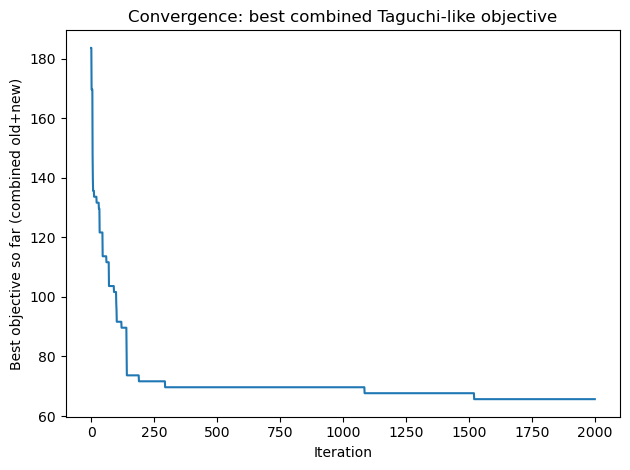

Random baseline (old fixed): 100%|██████████| 300/300 [00:12<00:00, 24.31design/s]


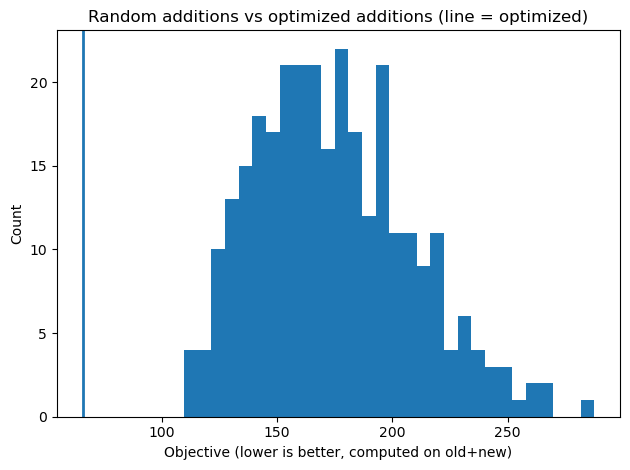

Baseline mean objective: 174.45
Baseline best objective: 109.67
Optimized objective:     65.67


,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition Num,Anneal Temp (°C)
0,10,25,3.0,2,2,150
1,20,25,0.3,2,2,400
2,30,25,0.3,4,1,150
3,20,25,2.0,4,1,150
4,30,25,3.0,2,1,600
5,20,25,2.0,4,1,400
6,30,400,2.0,4,2,600
7,10,400,0.3,2,1,600
8,10,400,3.0,4,2,600


In [9]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from tqdm import tqdm

FACTORS = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
]

# -----------------------------
# 1) Define levels for NEW candidates (edit as needed)
# -----------------------------
levels = {
    "Power (W)": [10, 20, 30],
    "Substrate Temp (°C)": [25, 400],
    "O2 Flow (sccm)": [0.3, 2.0, 3.0],
    "Pressure (mTorr)": [2, 4],
    "Anneal Condition Num": [1, 2],
    "Anneal Temp (°C)": [150, 400, 600],  # example 3 levels
}

def all_candidates(levels_dict):
    keys = list(levels_dict.keys())
    rows = list(itertools.product(*[levels_dict[k] for k in keys]))
    return pd.DataFrame(rows, columns=keys)

# Candidates for NEW experiments only (constraint applied here)
cand = all_candidates(levels)
cand = cand[cand["Substrate Temp (°C)"] < cand["Anneal Temp (°C)"]].reset_index(drop=True)

# Optional: prevent selecting exact duplicates of OLD runs (usually what you want)
def row_key(df_row):
    return tuple(df_row[f] for f in FACTORS)

old_keys = set(row_key(r) for _, r in old[FACTORS].iterrows())
cand_keys = [row_key(r) for _, r in cand.iterrows()]
cand = cand[[k not in old_keys for k in cand_keys]].reset_index(drop=True)
cand_keys = [row_key(r) for _, r in cand.iterrows()]

print("Feasible NEW candidates (excluding duplicates of old):", len(cand))

# -----------------------------
# 2) Taguchi-like pairwise balance objective on COMBINED design
# -----------------------------
def taguchi_pairwise_objective(df_all, factors):
    N = len(df_all)
    obj = 0.0
    for i in range(len(factors)):
        for j in range(i + 1, len(factors)):
            fi, fj = factors[i], factors[j]
            tab = pd.crosstab(df_all[fi], df_all[fj]).sort_index(axis=0).sort_index(axis=1)
            Li, Lj = tab.shape
            ideal = N / (Li * Lj)
            dev = tab.values - ideal
            obj += float((dev ** 2).sum())
    return obj

def random_new_set(candidates, n_add, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(candidates), size=n_add, replace=False)
    return candidates.iloc[idx].reset_index(drop=True)

# -----------------------------
# 3) Optimize NEW set using swap search, but score COMBINED = old + new
# -----------------------------
def optimize_augmentation_by_swaps(old_df, candidates, n_add, factors, n_iters=30000, seed=0, tqdm_every=200):
    rng = np.random.default_rng(seed)

    # initial new
    new_df = random_new_set(candidates, n_add, seed=seed)
    new_keys = set(row_key(r) for _, r in new_df.iterrows())

    combined = pd.concat([old_df[factors], new_df[factors]], ignore_index=True)
    cur_obj = taguchi_pairwise_objective(combined, factors)

    best_new = new_df.copy()
    best_obj = cur_obj

    hist_best = [best_obj]
    hist_cur = [cur_obj]

    pbar = tqdm(range(n_iters), desc="Augmenting (swap optimization)", unit="iter")
    for t in pbar:
        out_pos = int(rng.integers(0, n_add))
        out_key = row_key(new_df.iloc[out_pos])

        # pick candidate not already in NEW (and not duplicated with OLD due to pre-filter)
        in_idx = None
        for _ in range(50):
            j = int(rng.integers(0, len(candidates)))
            in_key = cand_keys[j]
            if in_key not in new_keys:
                in_idx = j
                break
        if in_idx is None:
            hist_best.append(best_obj)
            hist_cur.append(cur_obj)
            continue

        trial_new = new_df.copy()
        trial_new.iloc[out_pos] = candidates.iloc[in_idx]
        trial_combined = pd.concat([old_df[factors], trial_new[factors]], ignore_index=True)
        trial_obj = taguchi_pairwise_objective(trial_combined, factors)

        if trial_obj < cur_obj:
            # accept
            new_df = trial_new
            cur_obj = trial_obj
            new_keys.remove(out_key)
            new_keys.add(cand_keys[in_idx])

            if cur_obj < best_obj:
                best_obj = cur_obj
                best_new = new_df.copy()

        hist_best.append(best_obj)
        hist_cur.append(cur_obj)

        if (t % tqdm_every) == 0:
            pbar.set_postfix(cur=f"{cur_obj:.2f}", best=f"{best_obj:.2f}")

    return best_new.reset_index(drop=True), best_obj, np.array(hist_cur), np.array(hist_best)

# -----------------------------
# 4) Run augmentation
# -----------------------------
N_ADD = 9  # choose how many NEW experiments you want to add (18 is a good default)
best_new, best_obj, hist_cur, hist_best = optimize_augmentation_by_swaps(
    old, cand, N_ADD, FACTORS, n_iters=2000, seed=42
)

all_design = pd.concat([old[FACTORS], best_new[FACTORS]], ignore_index=True)

print("\nBest combined objective:", best_obj)
print("Total runs (old + new):", len(all_design))

# -----------------------------
# 5) Validation plot: compare against RANDOM additions (old fixed)
# -----------------------------
plt.figure()
plt.plot(hist_best)
plt.xlabel("Iteration")
plt.ylabel("Best objective so far (combined old+new)")
plt.title("Convergence: best combined Taguchi-like objective")
plt.tight_layout()
plt.show()

rng = np.random.default_rng(123)
n_baseline = 300
baseline = []
for _ in tqdm(range(n_baseline), desc="Random baseline (old fixed)", unit="design"):
    new0 = random_new_set(cand, N_ADD, seed=int(rng.integers(0, 1_000_000)))
    comb0 = pd.concat([old[FACTORS], new0[FACTORS]], ignore_index=True)
    baseline.append(taguchi_pairwise_objective(comb0, FACTORS))
baseline = np.array(baseline)

plt.figure()
plt.hist(baseline, bins=30)
plt.axvline(best_obj, linewidth=2)
plt.xlabel("Objective (lower is better, computed on old+new)")
plt.ylabel("Count")
plt.title("Random additions vs optimized additions (line = optimized)")
plt.tight_layout()
plt.show()

print(f"Baseline mean objective: {baseline.mean():.2f}")
print(f"Baseline best objective: {baseline.min():.2f}")
print(f"Optimized objective:     {best_obj:.2f}")

# best_new are the NEW experiments to run
best_new


In [10]:
best_new.to_excel("new_design.xlsx")

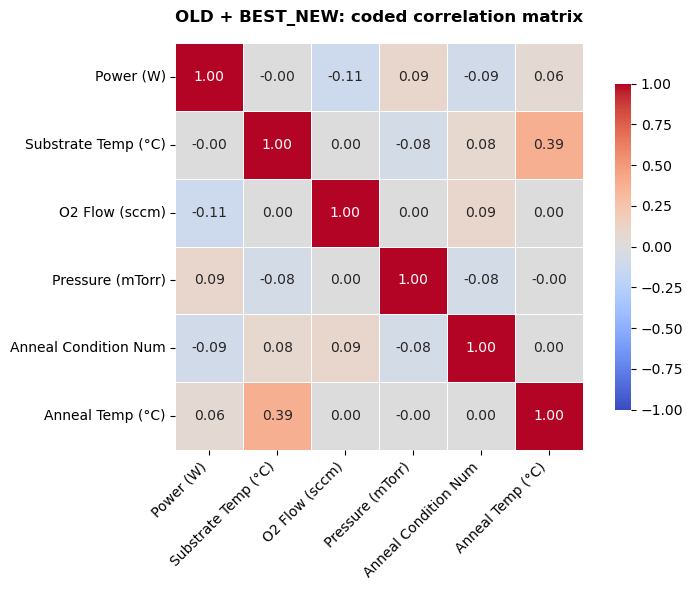

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is installed (pip install seaborn)

def code_levels(df, factors):
    """
    Code each factor to numeric values centered around 0.
    - 1 level -> 0
    - 2 levels -> [-1, +1]
    - 3 levels -> [-1, 0, +1]
    - k levels -> equally spaced in [-1, +1]
    """
    coded = pd.DataFrame(index=df.index)
    for f in factors:
        lvls = sorted(df[f].dropna().unique())
        k = len(lvls)
        if k == 0:
            coded[f] = 0.0
            continue
        if k == 1:
            mapping = {lvls[0]: 0.0}
        elif k == 2:
            mapping = {lvls[0]: -1.0, lvls[1]: +1.0}
        elif k == 3:
            mapping = {lvls[0]: -1.0, lvls[1]: 0.0, lvls[2]: +1.0}
        else:
            vals = np.linspace(-1.0, 1.0, k)
            mapping = {lv: float(v) for lv, v in zip(lvls, vals)}
        coded[f] = df[f].map(mapping).astype(float)
    return coded

def plot_corr_heatmap_improved(df, factors, title="Coded correlation matrix (orthogonality proxy)"):
    coded = code_levels(df, factors)
    # Pandas returns a DataFrame, keep it as a DataFrame for Seaborn to use the column names
    corr = coded.corr().fillna(0.0) 

    plt.figure(figsize=(8, 6)) # Adjust size as needed
    
    # Seaborn heatmap automatically handles text contrast, formatting, and colormaps
    sns.heatmap(
        corr, 
        vmin=-1, vmax=1, center=0, 
        cmap="coolwarm",       # Diverging colormap (Blue -> White -> Red)
        annot=True,            # Show numbers
        fmt=".2f",             # Format to 2 decimal places
        square=True,           # Force cells to be perfect squares
        linewidths=0.5,        # Add grid lines between cells for clarity
        cbar_kws={"shrink": 0.8} # Slightly shrink colorbar to match matrix height
    )
    
    plt.title(title, pad=15, weight='bold')
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Combine old + best_new (only factor columns)
all_design = pd.concat([old[FACTORS], best_new[FACTORS]], ignore_index=True)

# Plot correlation heatmap for the combined design
plot_corr_heatmap_improved(all_design, FACTORS, title="OLD + BEST_NEW: coded correlation matrix")

In [12]:
display(all_design)
all_design.to_excel("output/new_design.xlsx")

,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition Num,Anneal Temp (°C)
0,10,25,0.3,2,1,150
1,10,25,0.3,4,2,400
2,10,400,3.0,2,1,400
3,10,400,3.0,4,2,150
4,30,25,3.0,4,1,400
5,30,25,3.0,2,2,150
6,30,400,0.3,2,2,400
7,30,400,0.3,4,1,150
8,20,25,3.0,4,2,400
9,30,25,0.3,4,1,600


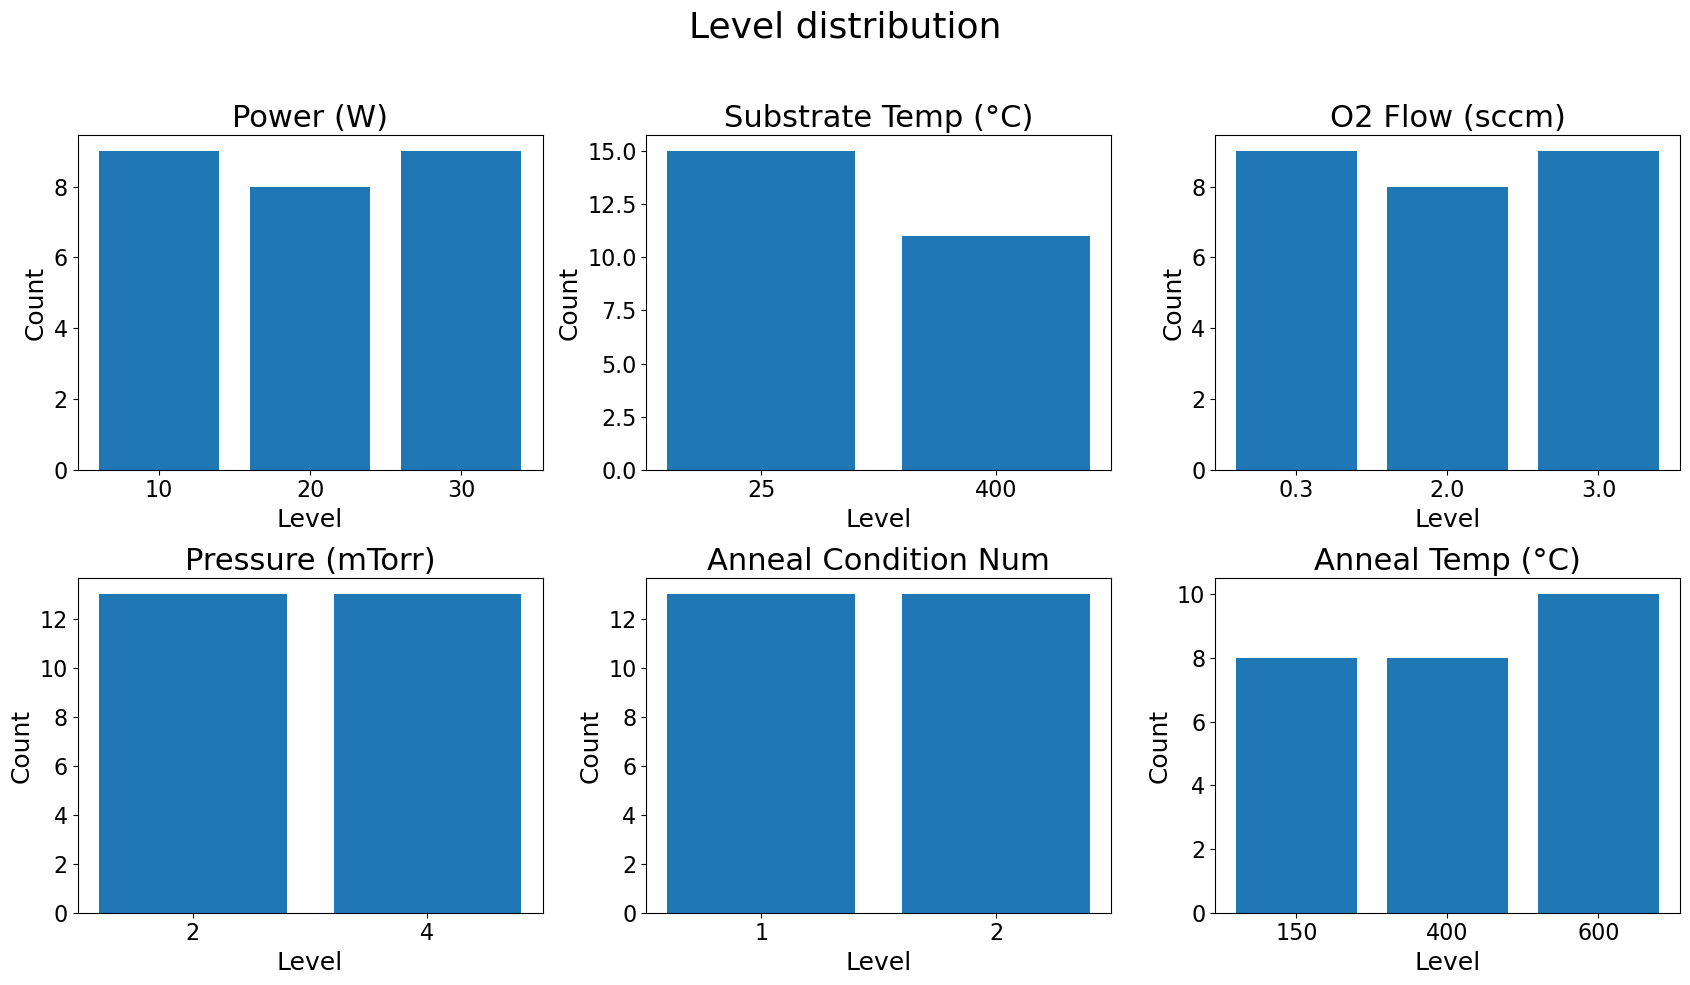

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_level_balance_grid(df, factors, title="Level distribution (combined)"):
    nrows, ncols = 2, 3  # 2x3 layout

    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 10))
    axes = axes.flatten()

    for i, f in enumerate(factors):
        ax = axes[i]
        vc = df[f].value_counts().sort_index()
        ax.bar([str(x) for x in vc.index], vc.values)

        ax.set_title(f, fontsize=22)
        ax.set_ylabel("Count", fontsize=18)
        ax.set_xlabel("Level", fontsize=18)

        # make tick labels bigger
        ax.tick_params(axis="both", labelsize=16)

    # Turn off unused axes
    for j in range(i + 1, nrows * ncols):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=26)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


all_design = pd.concat([old[FACTORS], best_new[FACTORS]], ignore_index=True)

plot_level_balance_grid(
    all_design,
    FACTORS,
    title="Level distribution"
)


In [14]:
import pandas as pd

FACTORS = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
]

# Conventional mixed Taguchi total size
N_TOTAL = 36  # L36

# Your desired discrete levels (including your new 600°C level)
DESIRED_LEVELS = {
    "Power (W)": [10, 20, 30],
    "Substrate Temp (°C)": [25, 400],
    "O2 Flow (sccm)": [0.3, 2.0, 3.0],
    "Pressure (mTorr)": [2, 4],
    "Anneal Condition Num": [1, 2],
    "Anneal Temp (°C)": [150, 400, 600],  # <-- your choice
}

# If old has replicates in the raw file, make sure old is one row per Experiment already.
# If your `old` is already aggregated (one row per Experiment), this is fine.
old_runs = old[FACTORS].drop_duplicates().copy()

N_OLD = len(old_runs)
N_ADD_TARGET = N_TOTAL - N_OLD
print("N_OLD =", N_OLD)
print("N_TOTAL =", N_TOTAL)
print("To reach L36 total, you would add N_ADD =", N_ADD_TARGET)

# ---------- Level-balance target table ----------
rows = []
for f in FACTORS:
    levels = DESIRED_LEVELS[f]
    L = len(levels)
    target_per_level = N_TOTAL / L

    counts_old = old_runs[f].value_counts().reindex(levels, fill_value=0)

    for lvl in levels:
        cur = int(counts_old.loc[lvl])
        tgt = target_per_level
        rows.append({
            "Factor": f,
            "Level": lvl,
            "Old count": cur,
            f"Target count in N={N_TOTAL}": tgt,
            "Deficit (target - old)": tgt - cur,
        })

balance_table = pd.DataFrame(rows)
balance_table[f"Target count in N={N_TOTAL}"] = balance_table[f"Target count in N={N_TOTAL}"].round(2)
balance_table["Deficit (target - old)"] = balance_table["Deficit (target - old)"].round(2)

balance_table


N_OLD = 17
N_TOTAL = 36
To reach L36 total, you would add N_ADD = 19


,Factor,Level,Old count,Target count in N=36,Deficit (target - old)
0,Power (W),10.0,6,12.0,6.0
1,Power (W),20.0,5,12.0,7.0
2,Power (W),30.0,6,12.0,6.0
3,Substrate Temp (°C),25.0,9,18.0,9.0
4,Substrate Temp (°C),400.0,8,18.0,10.0
5,O2 Flow (sccm),0.3,6,12.0,6.0
6,O2 Flow (sccm),2.0,5,12.0,7.0
7,O2 Flow (sccm),3.0,6,12.0,6.0
8,Pressure (mTorr),2.0,9,18.0,9.0
9,Pressure (mTorr),4.0,8,18.0,10.0


How many Taguchi rows are already in OLD: 3


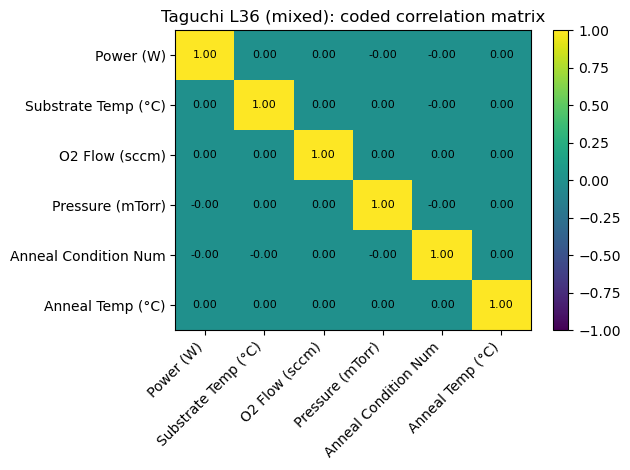

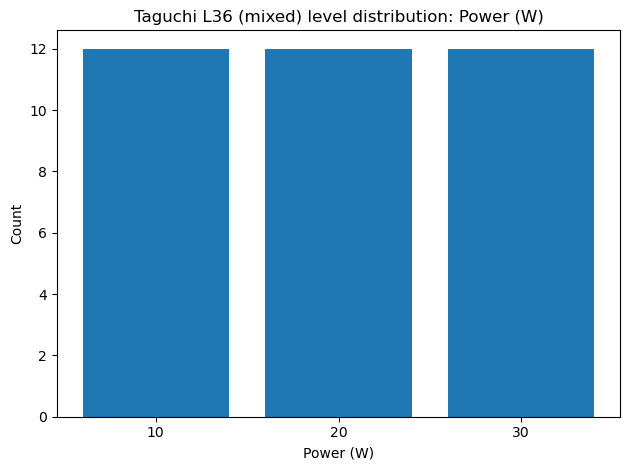

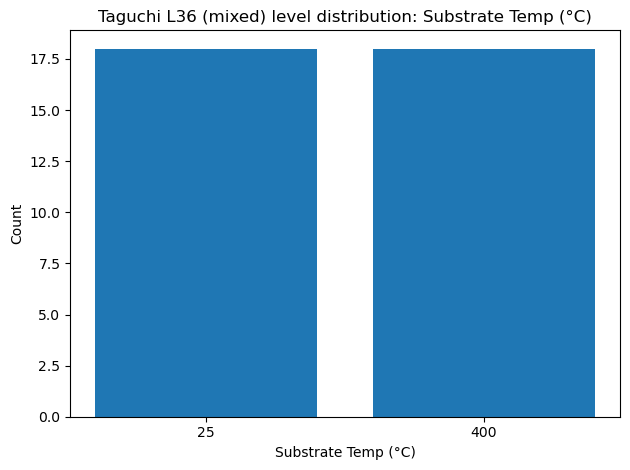

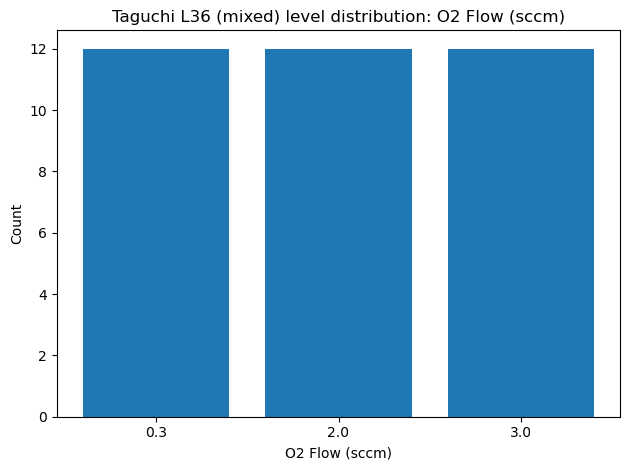

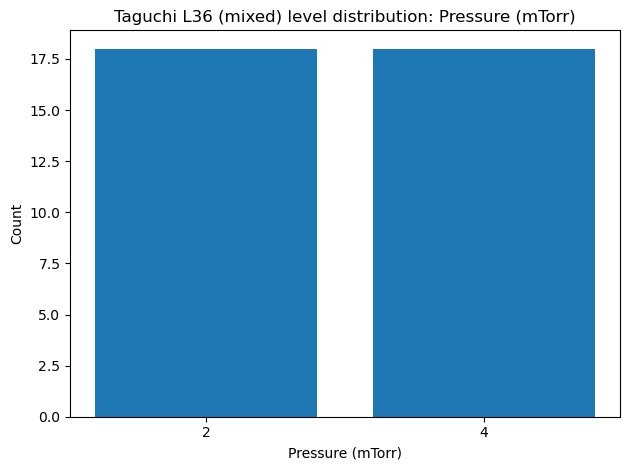

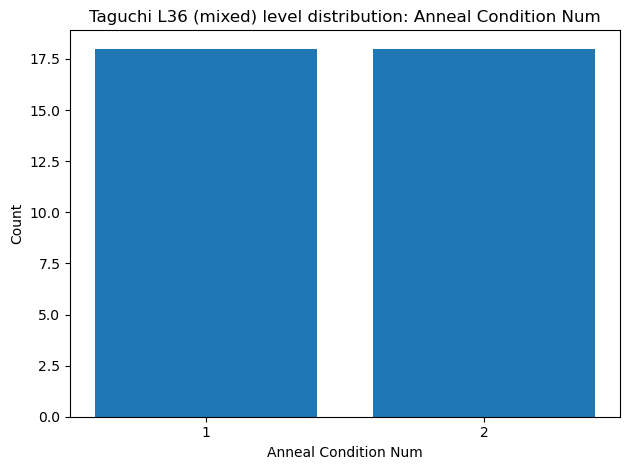

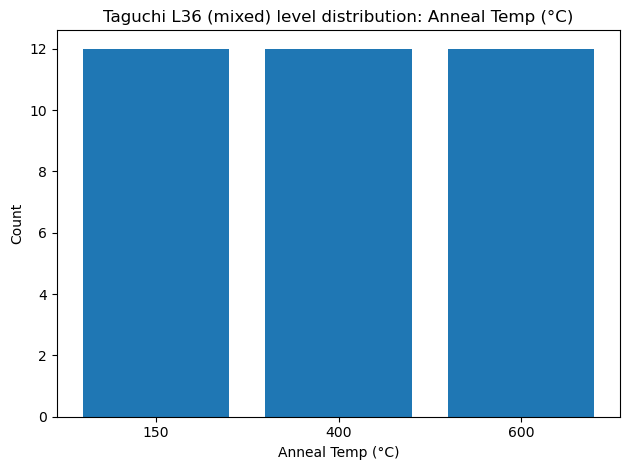

,Run,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition Num,Anneal Temp (°C),In OLD?
0,1,10,25,0.3,2,1,150,True
1,2,10,25,2.0,2,1,400,True
2,3,10,25,3.0,2,1,600,False
3,4,20,25,0.3,2,1,400,False
4,5,20,25,2.0,2,1,600,False
5,6,20,25,3.0,2,1,150,False
6,7,30,25,0.3,2,1,600,False
7,8,30,25,2.0,2,1,150,False
8,9,30,25,3.0,2,1,400,False
9,10,10,25,0.3,4,2,150,False


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Desired mixed-Taguchi levels
# ----------------------------
LEVELS = {
    "Power (W)": [10, 20, 30],
    "Substrate Temp (°C)": [25, 400],
    "O2 Flow (sccm)": [0.3, 2.0, 3.0],
    "Pressure (mTorr)": [2, 4],
    "Anneal Condition Num": [1, 2],
    "Anneal Temp (°C)": [150, 400, 600],
}

FACTORS = list(LEVELS.keys())

# ----------------------------
# Mixed Taguchi (36-run) table
# (this is the exact 36-run table provided earlier)
# ----------------------------
def build_mixed_taguchi_L36():
    rows = [
        (10,  25, 0.3, 2, 1, 150),
        (10,  25, 2.0, 2, 1, 400),
        (10,  25, 3.0, 2, 1, 600),
        (20,  25, 0.3, 2, 1, 400),
        (20,  25, 2.0, 2, 1, 600),
        (20,  25, 3.0, 2, 1, 150),
        (30,  25, 0.3, 2, 1, 600),
        (30,  25, 2.0, 2, 1, 150),
        (30,  25, 3.0, 2, 1, 400),

        (10,  25, 0.3, 4, 2, 150),
        (10,  25, 2.0, 4, 2, 400),
        (10,  25, 3.0, 4, 2, 600),
        (20,  25, 0.3, 4, 2, 400),
        (20,  25, 2.0, 4, 2, 600),
        (20,  25, 3.0, 4, 2, 150),
        (30,  25, 0.3, 4, 2, 600),
        (30,  25, 2.0, 4, 2, 150),
        (30,  25, 3.0, 4, 2, 400),

        (10, 400, 0.3, 2, 2, 150),
        (10, 400, 2.0, 2, 2, 400),
        (10, 400, 3.0, 2, 2, 600),
        (20, 400, 0.3, 2, 2, 400),
        (20, 400, 2.0, 2, 2, 600),
        (20, 400, 3.0, 2, 2, 150),
        (30, 400, 0.3, 2, 2, 600),
        (30, 400, 2.0, 2, 2, 150),
        (30, 400, 3.0, 2, 2, 400),

        (10, 400, 0.3, 4, 1, 150),
        (10, 400, 2.0, 4, 1, 400),
        (10, 400, 3.0, 4, 1, 600),
        (20, 400, 0.3, 4, 1, 400),
        (20, 400, 2.0, 4, 1, 600),
        (20, 400, 3.0, 4, 1, 150),
        (30, 400, 0.3, 4, 1, 600),
        (30, 400, 2.0, 4, 1, 150),
        (30, 400, 3.0, 4, 1, 400),
    ]
    df = pd.DataFrame(rows, columns=FACTORS)
    df.insert(0, "Run", np.arange(1, len(df) + 1))
    return df

taguchi36 = build_mixed_taguchi_L36()

# ----------------------------
# Helpers: coding + plots
# ----------------------------
def code_levels(df, factors, levels_map):
    coded = pd.DataFrame(index=df.index)
    for f in factors:
        lvls = levels_map[f]
        k = len(lvls)
        if k == 1:
            mapping = {lvls[0]: 0.0}
        elif k == 2:
            mapping = {lvls[0]: -1.0, lvls[1]: +1.0}
        elif k == 3:
            mapping = {lvls[0]: -1.0, lvls[1]: 0.0, lvls[2]: +1.0}
        else:
            vals = np.linspace(-1.0, 1.0, k)
            mapping = {lv: float(v) for lv, v in zip(lvls, vals)}
        coded[f] = df[f].map(mapping).astype(float)
    return coded

def plot_corr_heatmap(df, factors, levels_map, title="Coded correlation matrix"):
    coded = code_levels(df, factors, levels_map)
    corr = coded.corr().fillna(0.0).values
    labels = coded.columns.tolist()

    plt.figure()
    im = plt.imshow(corr, vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.title(title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

def plot_level_balance(df, factors, title_prefix="Level distribution"):
    for f in factors:
        plt.figure()
        vc = df[f].value_counts().sort_index()
        plt.bar([str(x) for x in vc.index], vc.values)
        plt.xlabel(f)
        plt.ylabel("Count")
        plt.title(f"{title_prefix}: {f}")
        plt.tight_layout()
        plt.show()

# ----------------------------
# (Optional) Mark which Taguchi rows match OLD runs
# ----------------------------
def to_key_frame(df, factors):
    return df[factors].astype(object).apply(lambda r: tuple(r.values.tolist()), axis=1)

if "old" in globals():
    old_unique = old[FACTORS].drop_duplicates().copy()
    old_keys = set(to_key_frame(old_unique, FACTORS))
    taguchi36["In OLD?"] = to_key_frame(taguchi36, FACTORS).isin(old_keys)
    print("How many Taguchi rows are already in OLD:", int(taguchi36["In OLD?"].sum()))
else:
    print("No `old` dataframe found in globals(); skipping OLD match flag.")

# ----------------------------
# Plots for the Taguchi 36 design
# ----------------------------
plot_corr_heatmap(taguchi36, FACTORS, LEVELS, title="Taguchi L36 (mixed): coded correlation matrix")
plot_level_balance(taguchi36, FACTORS, title_prefix="Taguchi L36 (mixed) level distribution")

# If you also want to see the combined OLD + Taguchi36 distribution/corr, uncomment:
# if "old" in globals():
#     combined = pd.concat([old_unique[FACTORS], taguchi36[FACTORS]], ignore_index=True)
#     plot_corr_heatmap(combined, FACTORS, LEVELS, title="OLD + Taguchi36: coded correlation matrix")
#     plot_level_balance(combined, FACTORS, title_prefix="OLD + Taguchi36 level distribution")

taguchi36


In [16]:
# --- postamble: persist master_df for downstream analysis notebook ---
import os
os.makedirs('output', exist_ok=True)
master_df.to_pickle('output/master_df.pkl')
print('saved output/master_df.pkl with shape', master_df.shape)


saved output/master_df.pkl with shape (51, 42)


# TEst of taguchi mixed level 

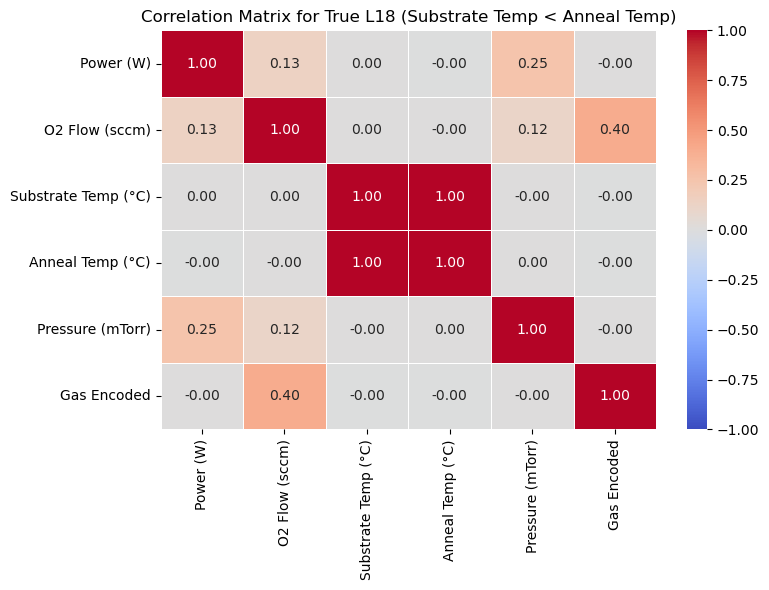

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# The standard formal L18 Taguchi array (first 5 columns used)
# Col 0: 2-Level Factor (Gas)
# Col 1-4: 3-Level Factors
l18_standard = [
    [1, 1, 1, 1, 1],
    [1, 1, 2, 2, 2],
    [1, 1, 3, 3, 3],
    [1, 2, 1, 1, 2],
    [1, 2, 2, 2, 3],
    [1, 2, 3, 3, 1],
    [1, 3, 1, 2, 1],
    [1, 3, 2, 3, 2],
    [1, 3, 3, 1, 3],
    [2, 1, 1, 3, 3],
    [2, 1, 2, 1, 1],
    [2, 1, 3, 2, 2],
    [2, 2, 1, 2, 3],
    [2, 2, 2, 3, 1],
    [2, 2, 3, 1, 2],
    [2, 3, 1, 3, 2],
    [2, 3, 2, 1, 3],
    [2, 3, 3, 2, 1]
]

gas_map = {1: 'N2', 2: 'O2'}
power_levels = {1: 10, 2: 20, 3: 40}  
o2_flow_levels = {1: 0.3, 2: 2.0, 3: 3.0}
temp_pairs = {1: (425, 500), 2: (500, 600), 3: (600, 600)}
pressure_levels = {1: 2, 2: 3, 3: 5}

runs = []
for row in l18_standard:
    sub_temp, ann_temp = temp_pairs[row[3]]
    runs.append({
        'Gas Type': gas_map[row[0]],
        'Power (W)': power_levels[row[1]],
        'O2 Flow (sccm)': o2_flow_levels[row[2]],
        'Substrate Temp (°C)': sub_temp,
        'Anneal Temp (°C)': ann_temp,
        'Pressure (mTorr)': pressure_levels[row[4]]
    })

df = pd.DataFrame(runs)
df['Gas Encoded'] = df['Gas Type'].map({'N2': -1, 'O2': 1})

# Filter out the 600/600 runs
df_filtered = df[df['Substrate Temp (°C)'] < df['Anneal Temp (°C)']]

# Calculate Correlation (dropping string columns)
corr_matrix = df_filtered.drop(columns=['Gas Type']).corr()

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix for True L18 (Substrate Temp < Anneal Temp)')
plt.tight_layout()
plt.show()